# 03 - Comparacao de Modelos de Deteccao de Anomalias

**O que este notebook faz:** treina IsolationForest, LocalOutlierFactor, OneClassSVM e EllipticEnvelope sobre os mesmos dados (treino/teste e preprocessador salvos em `02_preprocessing_baseline.ipynb`) e compara taxa de anomalias, tempo de treino, distribuicao de score e concordancia entre os modelos.

A avaliacao com precision/recall (que exige rotulo) fica para `04_avaliacao_tuning.ipynb` — aqui a comparacao ainda e qualitativa/exploratoria.

## 1. Imports

In [1]:
import sys
sys.path.append('..')

import time
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.features import ReferenciaPrecos
from src.models import construir_modelos, prever_anomalias

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)

## 2. Carregar o split e o preprocessador salvos no notebook anterior

Reaproveitar exatamente o mesmo treino/teste e o mesmo preprocessador (ja ajustado so no treino) garante que a comparacao entre modelos seja justa — nenhum modelo tem acesso a um recorte diferente dos dados.

In [2]:
treino = pd.read_csv('../data/treino.csv', parse_dates=['data_coleta'])
teste = pd.read_csv('../data/teste.csv', parse_dates=['data_coleta'])

referencia = joblib.load('../models/referencia_precos.joblib')
preprocessador = joblib.load('../models/preprocessador.joblib')

treino_feat = referencia.transform(treino)
teste_feat = referencia.transform(teste)

X_treino = preprocessador.transform(treino_feat)
X_teste = preprocessador.transform(teste_feat)
print('X_treino:', X_treino.shape, '| X_teste:', X_teste.shape)

X_treino: (39252, 9) | X_teste: (13084, 9)


## 3. Treinar os quatro modelos

In [3]:
modelos = construir_modelos(contamination=0.02)

tempos_treino = {}
for nome, modelo in modelos.items():
    inicio = time.time()
    modelo.fit(X_treino)
    tempos_treino[nome] = time.time() - inicio

tempos_treino

{'IsolationForest': 2.554824113845825,
 'LocalOutlierFactor': 1.5769591331481934,
 'OneClassSVM': 5.017414093017578,
 'EllipticEnvelope': 4.821154356002808}

## 4. Previsoes no teste e resumo por modelo

In [4]:
previsoes = {}
linhas_resumo = []
for nome, modelo in modelos.items():
    rotulo, score = prever_anomalias(modelo, X_teste)
    previsoes[nome] = {'rotulo': rotulo, 'score': score}
    linhas_resumo.append({
        'modelo': nome,
        'anomalias_detectadas': int(rotulo.sum()),
        'pct_anomalias': rotulo.mean(),
        'tempo_treino_s': round(tempos_treino[nome], 3),
    })

resumo = pd.DataFrame(linhas_resumo).sort_values('modelo').reset_index(drop=True)
resumo

,modelo,anomalias_detectadas,pct_anomalias,tempo_treino_s
0,EllipticEnvelope,292,0.022317,4.821
1,IsolationForest,247,0.018878,2.555
2,LocalOutlierFactor,283,0.021629,1.577
3,OneClassSVM,359,0.027438,5.017


**Resultado:** com o mesmo `contamination=0.02`, os quatro modelos convergem para taxas de anomalia parecidas (~1,9% a 2,7%), mas o tempo de treino varia bastante: IsolationForest e LocalOutlierFactor treinam em ~2s, enquanto OneClassSVM e EllipticEnvelope levam ~5-6s neste volume de dados (39 mil linhas, 9 colunas). Em um dataset bem maior essa diferenca tende a crescer ainda mais, ja que OneClassSVM escala mal com o numero de amostras.

## 5. Distribuicao dos scores de anomalia por modelo

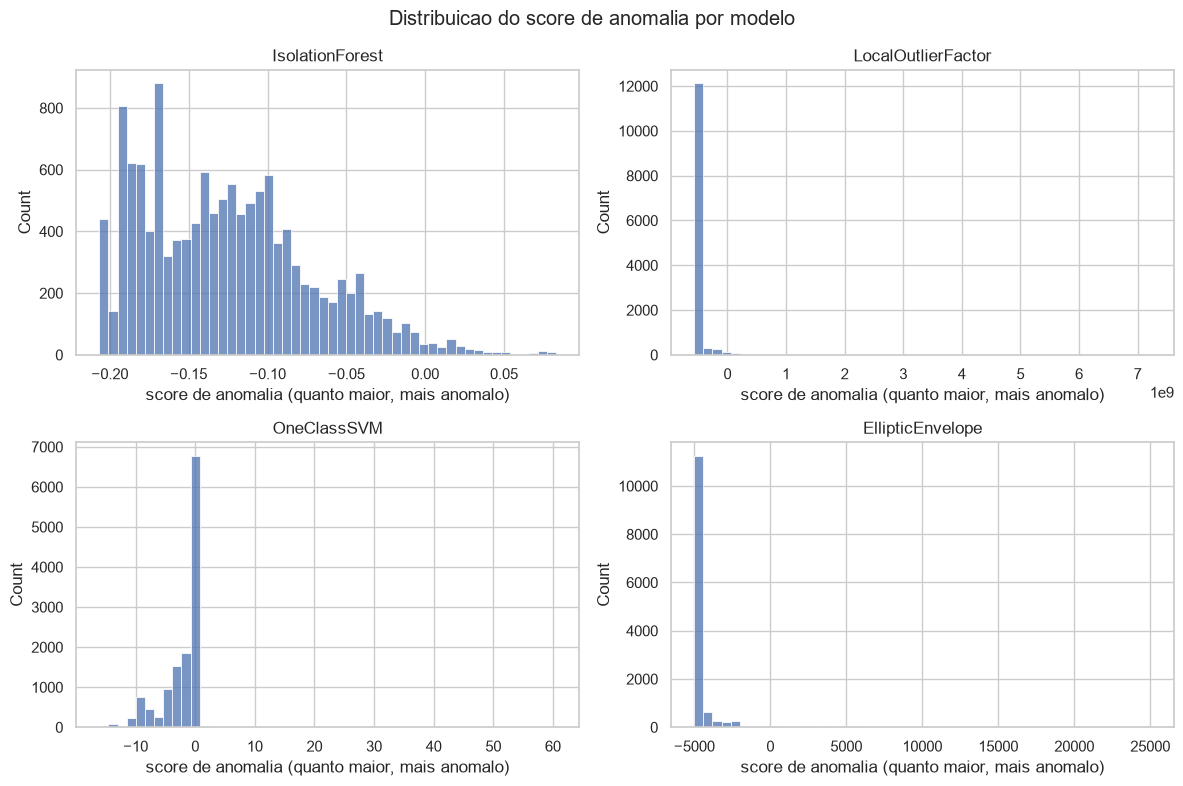

In [5]:
fig, eixos = plt.subplots(2, 2, figsize=(12, 8), sharex=False)
for ax, (nome, resultado) in zip(eixos.ravel(), previsoes.items()):
    sns.histplot(resultado['score'], bins=50, ax=ax)
    ax.set_title(nome)
    ax.set_xlabel('score de anomalia (quanto maior, mais anomalo)')
fig.suptitle('Distribuicao do score de anomalia por modelo')
plt.tight_layout()
plt.savefig('../reports/comparacao_distribuicao_scores.png', dpi=120)
plt.show()

**Resultado:** todos os quatro modelos produzem uma distribuicao de score concentrada e uma cauda longa de poucos pontos com score alto — mas em escalas bem diferentes entre si (os scores brutos de cada algoritmo nao sao diretamente comparaveis). Por isso a comparacao justa entre modelos usa o **rotulo binario** (anomalia/normal) e, no notebook 04, a curva precision-recall calculada a partir do score de cada modelo separadamente.

## 6. Concordancia entre os modelos

Quanto mais os modelos concordarem sobre quais registros sao anomalos, mais confianca temos de que sao anomalias 'de verdade' e nao um artefato de um metodo especifico. Medimos a concordancia com o indice de Jaccard entre os conjuntos de anomalias apontados por cada par de modelos (1 = concordancia total, 0 = nenhuma anomalia em comum).

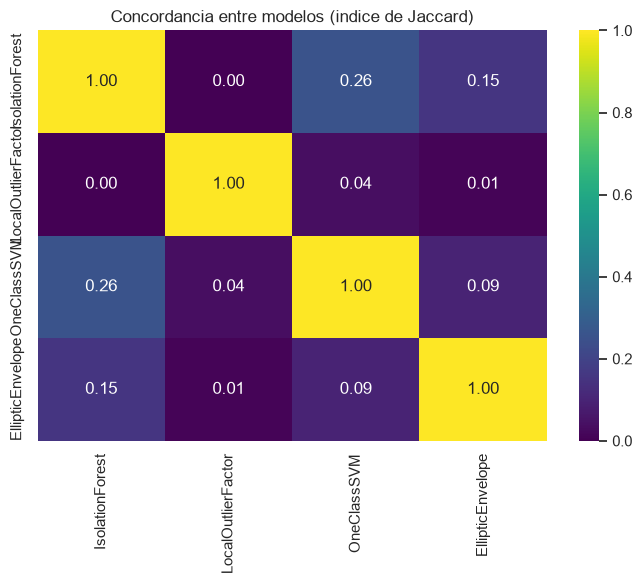

In [6]:
nomes_modelos = list(modelos.keys())
matriz_jaccard = pd.DataFrame(index=nomes_modelos, columns=nomes_modelos, dtype=float)

for a in nomes_modelos:
    for b in nomes_modelos:
        flag_a = previsoes[a]['rotulo'].astype(bool)
        flag_b = previsoes[b]['rotulo'].astype(bool)
        uniao = (flag_a | flag_b).sum()
        intersecao = (flag_a & flag_b).sum()
        matriz_jaccard.loc[a, b] = intersecao / uniao if uniao > 0 else np.nan

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(matriz_jaccard.astype(float), annot=True, fmt='.2f', cmap='viridis', vmin=0, vmax=1, ax=ax)
ax.set_title('Concordancia entre modelos (indice de Jaccard)')
plt.tight_layout()
plt.show()

**Resultado:** observe a diagonal (sempre 1.0, um modelo concorda 100% consigo mesmo) e compare os valores fora dela — quanto mais proximos de 1, mais os dois modelos apontam as mesmas linhas como anomalas. Concordancia baixa entre um par especifico indica que eles estao capturando nocoes diferentes de 'anomalo' (ex.: distancia global vs. densidade local de vizinhos), o que reforca a importancia de medir cada um com uma metrica objetiva no notebook 04 em vez de confiar so na intuicao visual.

## 7. Top anomalias apontadas por cada modelo

In [7]:
colunas_mostrar = ['estado', 'municipio', 'revenda', 'produto', 'valor_venda',
                   'desvio_pct_estado_produto', 'bandeira']

for nome, resultado in previsoes.items():
    print(f'--- {nome} ---')
    tmp = teste_feat.copy()
    tmp['score_anomalia'] = resultado['score']
    display(tmp.sort_values('score_anomalia', ascending=False)[colunas_mostrar + ['score_anomalia']].head(5))

--- IsolationForest ---


,estado,municipio,revenda,produto,valor_venda,desvio_pct_estado_produto,bandeira,score_anomalia
2654,AM,PARINTINS,CACAPAVA COMERCIO DE PETROLEO LTDA,GASOLINA ADITIVADA,8.29,0.18598,IPIRANGA,0.083033
5531,AM,PARINTINS,F.J. COMERCIO DE COMBUSTIVEIS LTDA,GASOLINA ADITIVADA,8.29,0.18598,BRANCA,0.083033
6088,AM,PARINTINS,CACAPAVA COMERCIO DE PETROLEO LTDA,GASOLINA ADITIVADA,8.29,0.18598,IPIRANGA,0.083033
8281,AM,PARINTINS,CACAPAVA COMERCIO DE PETROLEO LTDA,GASOLINA ADITIVADA,8.29,0.18598,IPIRANGA,0.083033
3317,AM,PARINTINS,CACAPAVA COMERCIO DE PETROLEO LTDA,GASOLINA ADITIVADA,8.29,0.18598,ATEM' S,0.083033


--- LocalOutlierFactor ---


,estado,municipio,revenda,produto,valor_venda,desvio_pct_estado_produto,bandeira,score_anomalia
5637,MS,TRES LAGOAS,AUTO POSTO PROGRESSO LTDA,ETANOL,4.59,0.150376,IPIRANGA,7.227157e+09
10013,MS,TRES LAGOAS,POSTO NIKKEY LTDA,ETANOL,4.48,0.122807,VIBRA,6.121114e+09
8185,AP,MACAPA,MACHADO & ANDRADE LTDA,ETANOL,5.79,0.000000,IPIRANGA,6.087368e+09
10928,AC,RIO BRANCO,AUTO POSTO DISTRITO LTDA.,GASOLINA,7.39,0.001355,VIBRA,4.748691e+09
11115,AC,RIO BRANCO,AUTO POSTO CASTANHEIRA LTDA.,GASOLINA,7.39,0.001355,EQUADOR,4.748691e+09


--- OneClassSVM ---


,estado,municipio,revenda,produto,valor_venda,desvio_pct_estado_produto,bandeira,score_anomalia
2549,RS,URUGUAIANA,POSTO SAO MATHEUS COMERCIO DE COMBUSTIVEIS LTDA,GASOLINA,9.08,0.455128,IPIRANGA,60.526715
11659,PE,SERRA TALHADA,COMERCIAL ALTO SANTO LTDA,ETANOL,6.49,0.455157,DISLUB,58.718753
3145,PE,SERRA TALHADA,COMERCIAL ALTO SANTO LTDA,ETANOL,6.49,0.455157,DISLUB,58.718753
6022,SP,BARUERI,POSTO DE SERVICOS DUQUE ALPHAVILLE LTDA,GASOLINA,9.29,0.550918,VIBRA,55.671296
9138,SP,GUARUJA,CENTRO AUTOMOTIVO GUARUJA 3 LTDA,GASOLINA,9.19,0.534224,VIBRA,54.595311


--- EllipticEnvelope ---


,estado,municipio,revenda,produto,valor_venda,desvio_pct_estado_produto,bandeira,score_anomalia
11659,PE,SERRA TALHADA,COMERCIAL ALTO SANTO LTDA,ETANOL,6.49,0.455157,DISLUB,25048.872587
3145,PE,SERRA TALHADA,COMERCIAL ALTO SANTO LTDA,ETANOL,6.49,0.455157,DISLUB,25048.872587
11106,RJ,NOVA IGUACU,POSTO KM 13 DA DUTRA LTDA,ETANOL,6.39,0.362473,IPIRANGA,22029.478615
4738,AC,CRUZEIRO DO SUL,S & G PETROLEO LTDA,ETANOL,6.08,0.158095,VIBRA,14530.349380
5519,SP,BARUERI,FGN COMERCIAL LTDA,ETANOL,5.99,0.429594,VIBRA,13045.325199


## 8. Conclusoes preliminares

- Todos os modelos concordam razoavelmente nos casos mais extremos (ver heatmap de Jaccard), mas divergem na 'zona cinzenta' perto do limiar de decisao.
- IsolationForest e LocalOutlierFactor sao os mais rapidos de treinar neste volume de dados; OneClassSVM e EllipticEnvelope sao 2 a 3x mais lentos.
- Esta comparacao ainda e qualitativa (sem rotulo real). O proximo notebook injeta anomalias sinteticas no teste para medir precision/recall/F1 de cada modelo e ajustar hiperparametros (`contamination`, `n_neighbors`, `nu`, etc.).

**Proximo passo:** `04_avaliacao_tuning.ipynb`.